In [1]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import re
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

In [2]:
AFR = 14.08  # air-fuel ratio for E10 fuel
AD = 1.225  # air density kg/m³

dataset_path = Path("../data/bg_dataset")

In [6]:
static_data = [file for file in dataset_path.iterdir() if str(file).endswith(".xlsx")]

static_data_dfs = pd.read_excel(static_data[0])

ids = static_data_dfs["VehId"]
enc_d = static_data_dfs["Engine Configuration & Displacement"]


def extract_displacement(en_conf_and_dis: str):
    pattern = r"([\d\.]+)L"
    displacement = re.findall(pattern, en_conf_and_dis)
    if len(displacement) == 0:
        return None
    try:
        return float(displacement[0])
    except Exception:
        print("Can't parse: ", displacement, en_conf_and_dis)

        return None


id_dis_mapping = {k: extract_displacement(v) for k in ids for v in enc_d}

In [7]:
tot = 0

miss_data_count = {}
fr_miss_after_approx = 0

global_df = pd.DataFrame()


def fr_reproduction(data_entity: pd.Series):
    fr = data_entity.get("Fuel Rate[L/hr]")
    if not pd.isna(fr):
        return fr

    # Evaluate correction

    st_ft_1 = data_entity["Short Term Fuel Trim Bank 1[%]"]
    lt_ft_1 = data_entity["Long Term Fuel Trim Bank 1[%]"]

    st_ft_2 = data_entity["Short Term Fuel Trim Bank 2[%]"]
    lt_ft_2 = data_entity["Long Term Fuel Trim Bank 2[%]"]

    if not pd.isna(st_ft_1) and not pd.isna(st_ft_2):
        st_ft = (st_ft_1 + st_ft_2) / 2
    elif not pd.isna(st_ft_1):
        st_ft = st_ft_1
    elif not pd.isna(st_ft_2):
        st_ft = st_ft_2
    else:
        return None

    if not pd.isna(lt_ft_1) and not pd.isna(lt_ft_2):
        lt_ft = (lt_ft_1 + lt_ft_2) / 2
    elif not pd.isna(lt_ft_1):
        lt_ft = lt_ft_1
    elif not pd.isna(lt_ft_2):
        lt_ft = lt_ft_2
    else:
        return None

    correction = (1 + st_ft / 100 + lt_ft / 100) * AFR

    # FR aproximation from original dataset paper

    if not pd.isna(maf := data_entity["MAF[g/sec]"]):
        return maf * correction
    elif not pd.isna(al := data_entity["Absolute Load[%]"]) and not pd.isna(
        rpm := data_entity["Engine RPM[RPM]"]
    ):
        if data_entity["VehId"] not in id_dis_mapping:
            return None

        eng_dis = id_dis_mapping[data_entity["VehId"]]

        if eng_dis is None:
            return None

        maf = al / 100 * AD * eng_dis * rpm / 120
        return maf * correction
    else:
        return None


for file in tqdm(dataset_path.iterdir()):
    if str(file).endswith(".csv"):
        df = pd.read_csv(file)
        namask = df.isna()
        d_length = len(df)

        # Counts NaN elements per column and comulates them
        for col in df.columns:
            if col not in miss_data_count:
                miss_data_count[col] = 0

            miss_data_count[col] += namask[col].sum()

        df["Fuel Rate[L/hr]"] = df.apply(fr_reproduction, axis=1)

        fr_miss_after_approx += df.isna()["Fuel Rate[L/hr]"].sum()

        global_df = pd.concat([global_df, df])

        tot += d_length

print(f"Total {tot} entities recieved\n")

print("Table of missed values")
for col in miss_data_count.keys():
    print(
        f"{str(col):.<35}{miss_data_count[col]:<10} {(miss_data_count[col]) / tot:.2%}"
    )

print(
    f"\nFuel Rate misses after approximation: {fr_miss_after_approx:<10} {fr_miss_after_approx / tot:.2%}"
)

56it [03:24,  3.66s/it]

Total 22436808 entities recieved

Table of missed values
DayNum.............................0          0.00%
VehId..............................0          0.00%
Trip...............................0          0.00%
Timestamp(ms)......................0          0.00%
Latitude[deg]......................0          0.00%
Longitude[deg].....................0          0.00%
Vehicle Speed[km/h]................1396       0.01%
MAF[g/sec].........................4178670    18.62%
Engine RPM[RPM]....................482305     2.15%
Absolute Load[%]...................5965212    26.59%
OAT[DegC]..........................9368517    41.76%
Fuel Rate[L/hr]....................21540711   96.01%
Air Conditioning Power[kW].........21542533   96.01%
Air Conditioning Power[Watts]......19602431   87.37%
Heater Power[Watts]................21558450   96.09%
HV Battery Current[A]..............18708156   83.38%
HV Battery SOC[%]..................18708156   83.38%
HV Battery Voltage[V]..............18708156   83.3

Fuel Rate Statistics
mean: 142.7784528339437, std: 151.20139521012027


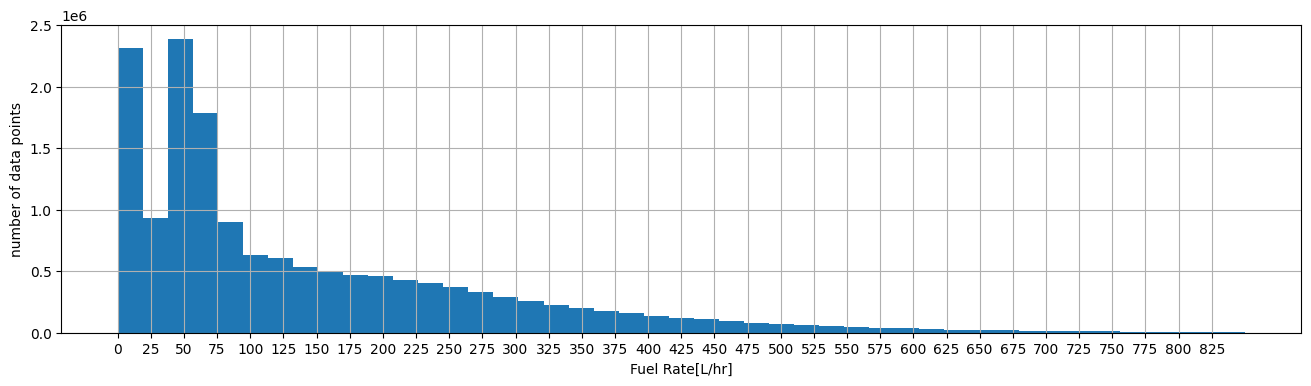

In [9]:
print("Fuel Rate Statistics")
print(
    f"mean: {np.mean(global_df['Fuel Rate[L/hr]'])}, std: {np.std(global_df['Fuel Rate[L/hr]'])}"
)

plt.figure(figsize=(16, 4))
plt.hist(
    global_df["Fuel Rate[L/hr]"],
    bins=45,
    range=(0, 850),
)
plt.ylabel("number of data points")
plt.xlabel("Fuel Rate[L/hr]")
plt.grid(True)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.xticks(np.arange(0, 850, 25))
plt.show()

In [6]:
static_data = pd.concat(
    [
        pd.read_excel("../data/VED_Static_Data_ICE&HEV.xlsx"),
        pd.read_excel("../data/VED_Static_Data_PHEV&EV.xlsx"),
    ]
)
static_data

,VehId,Vehicle Type,Vehicle Class,Engine Configuration & Displacement,Transmission,Drive Wheels,Generalized_Weight,EngineType
0,2,ICE,Car,4-FI 2.0L T/C,NO DATA,NO DATA,3500,NaN
1,5,HEV,Car,4-GAS/ELECTRIC 2.0L,NO DATA,NO DATA,3500,NaN
2,7,ICE,SUV,6-FI 3.6L,AUTOMATIC,NO DATA,4500,NaN
3,8,ICE,Car,4-FI 1.5L,5-SP MANUAL,NO DATA,2500,NaN
4,12,ICE,Car,4-FI 1.8L,NO DATA,NO DATA,2500,NaN
...,...,...,...,...,...,...,...,...
22,554,NaN,Car,4-GAS/ELECTRIC 1.4L,NO DATA,FWD,4000,PHEV
23,560,NaN,Car,4-GAS/ELECTRIC 1.8L,CVT,FWD,3000,PHEV
24,561,NaN,Car,4-GAS/ELECTRIC 2.0L,CVT,FWD,4000,PHEV
25,567,NaN,Car,4-GAS/ELECTRIC 1.4L,NO DATA,FWD,4000,PHEV


In [34]:
data_folder = Path("../data")

trips_df = None
trips_list_df = None

for weekly_trips_file in data_folder.glob("*.csv"):
    df = pd.read_csv(weekly_trips_file)

    trips = df.drop(["DayNum", "VehId"], axis=1)
    trips_list = df[["Trip", "VehId", "DayNum"]].drop_duplicates()

    if trips_df is None:
        trips_df = trips
    else:
        trips_df = pd.concat([trips_df, trips])

    if trips_list_df is None:
        trips_list_df = trips_list
    else:
        trips_list_df = pd.concat([trips_list_df, trips_list])


trips_df.head()

KeyError: "['DayNum', 'VehId'] not found in axis"

In [32]:
trips_list_df.to_csv("../data/trips_list.csv", index=False, na_rep="null")
trips.to_csv("../data/trips.csv", index=False, na_rep="null")

In [ ]:
import re

static_data = pd.concat(
    [
        pd.read_excel("../data/VED_Static_Data_ICE&HEV.xlsx"),
        pd.read_excel("../data/VED_Static_Data_PHEV&EV.xlsx"),
    ]
)
static_data


def convert_l(string: str):
    dis = re.findall(r"(\d\.\d)L", string)
    conf = re.sub(r"\d\.\dL", "", string).strip()
    if len(dis) == 0:
        return None, conf
    if conf == "":
        conf = None
    return float(dis[0]), conf


def process_static_data(dataframe: pd.DataFrame) -> pd.DataFrame:
    dataframe["eng_dis"] = dataframe["Engine Configuration & Displacement"].apply(
        lambda x: convert_l(x)[0]
    )
    dataframe["eng_conf"] = dataframe["Engine Configuration & Displacement"].apply(
        lambda x: convert_l(x)[1]
    )
    dataframe.drop(["Engine Configuration & Displacement"], axis=1, inplace=True)
    dataframe.rename(
        columns={
            "VehId": "vehid",
            "Vehicle Type": "vehtype",
            "Vehicle Class": "vehclass",
            "EngineType": "eng_type",
            "Transmission": "transmission",
            "Drive Wheels": "drive_wheels",
            "Generalized_Weight": "gen_weight",
        },
        inplace=True,
    )
    dataframe.replace("NO DATA", None, inplace=True)
    return dataframe


process_static_data(static_data).to_csv(
    "../data/vehicles.csv", index=False, na_rep="null"
)

In [35]:
trips_df = pd.read_csv("../data/trips.csv")

trips_df.head()

,tripid,time,lat,long,speed,maf,rpm,abs_load,oat,fuel_rate,air_cp_kw,air_cp_watts,heater_power,hv_battery_current,hv_battery_soc,hv_battery_vol,stfb_1,stfb_2,ltfb_1,ltfb_2
0,706,0,42.277558,-83.69875,40.0,22.129999,2285.0,49.019608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,706,200,42.277558,-83.69875,40.0,22.129999,2285.0,67.450981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,706,1100,42.277558,-83.69875,45.0,22.129999,2285.0,67.450981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,706,2100,42.277558,-83.69875,47.0,6.150000,2744.0,67.450981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,706,4200,42.277558,-83.69875,48.0,21.440001,1982.0,67.450981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
trips_list_df = pd.read_csv("../data/trips_list.csv")

trips_list_df.head()

,tripid,vehid,daynum
0,706,8,1.586651
1,707,8,1.931786
2,1558,10,1.719774
3,1485,11,1.058991
4,755,124,1.701753


In [129]:
from matplotlib.collections import LineCollection

df = trips_df

x = df["lat"].values
y = df["long"].values
speed = df["speed"].values

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = plt.Normalize(speed.min(), speed.max())
lc = LineCollection(segments, cmap="viridis", norm=norm)

lc.set_array(speed)

plt.gca().add_collection(lc)
plt.xlim(x.min(), x.max())
plt.ylim(y.min(), y.max())

plt.colorbar(lc, label="Speed")
plt.show()

KeyboardInterrupt: 